# 认识RAG
大型语言模型（LLMs）功能强大，但存在几个关键局限性：
- 知识局限性：模型的回答都来自于训练数据，对于完全未接触过的专业领域，无法给出正确的答案
- 时间局限性：模型训练数据都来自于历史数据，比如DeepSeek的训练数据截止于2025年，无法回答实时问题

而要解决这些问题，就需要用到RAG技术了。

本章，我们就学习RAG技术，以及LangChain中如何实现RAG.

## 1. 认识RAG
RAG，Retrieval-Augmented Generation，就是检索增强生成的意思。既，通过检索加载额外的知识作为上下文信息来增强LLM的回答。

### 1.1 LLM的幻觉
举例来说，某保险公司开发了一个自己的智能客服，希望智能客服可以7*24小时在线，回答用户与自家的保险产品、条款、理赔有关的问题。

但是，受限于知识局限性，LLM对这家保险公司的产品、理赔条款完全不知道，是没办法回答的。如果强行回答，只能说一本正经的胡说八道，也就是所谓的幻觉。
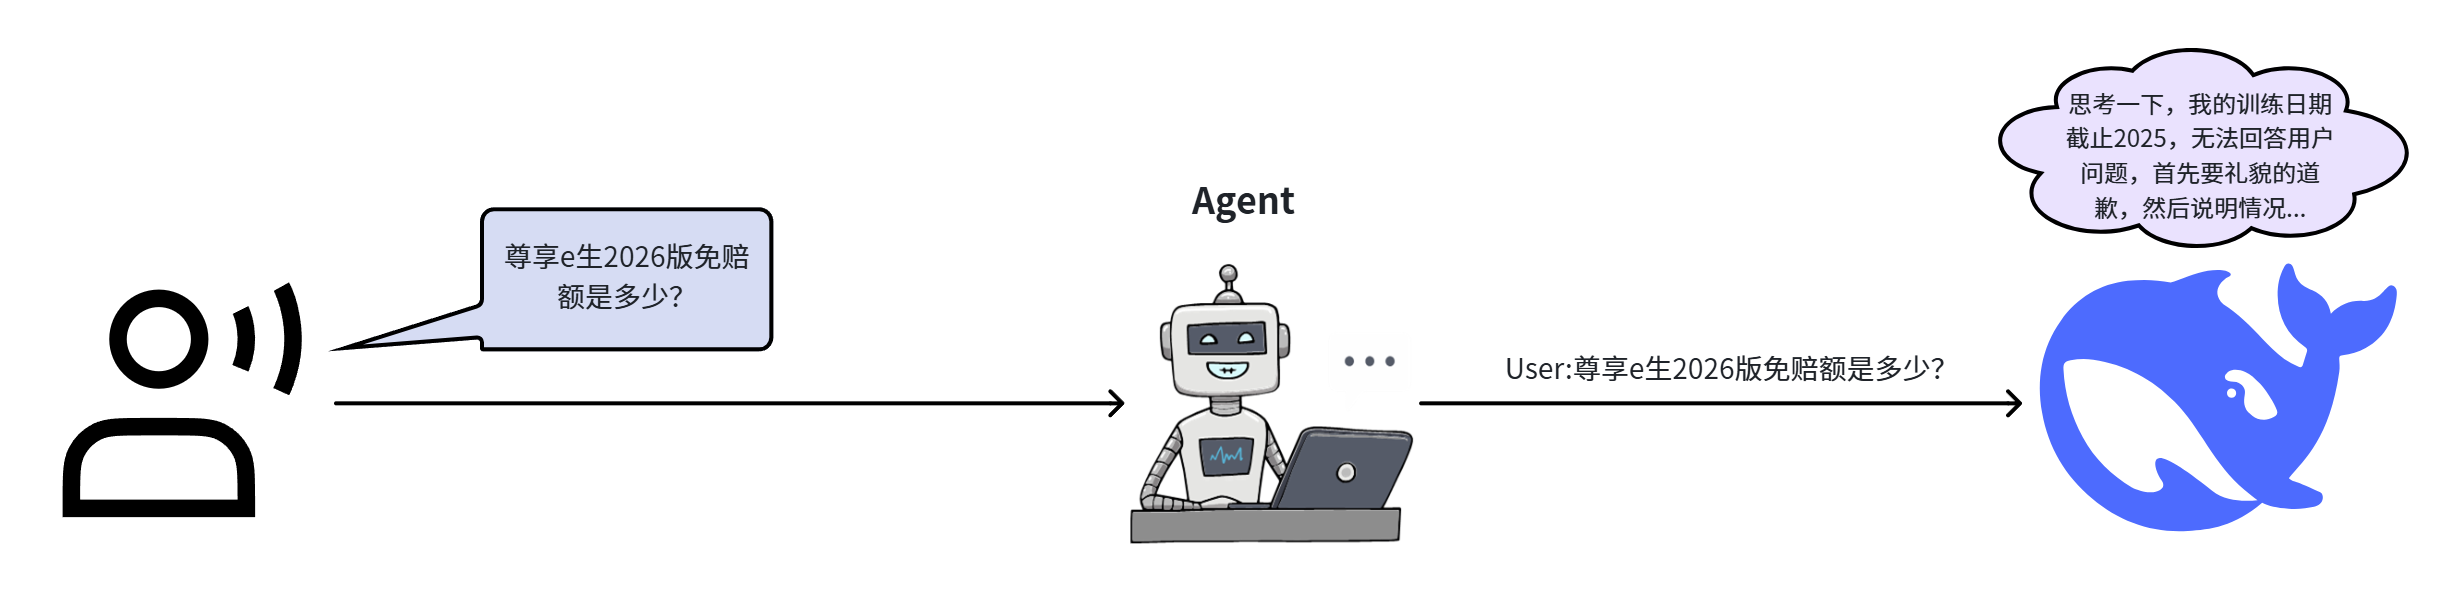

### 1.2 外挂知识库
按照RAG的思想，我们可以把LLM不知道的知识作为提示词的一部分发送给他，这样LLM就可以根据提示词中的知识来回答用户问题了。

例如：AI保险客服不知道保险合同条款，当用户提问时，我们可以把保险公司的所有保险条款和用户问题都作为提示词，一起给模型：
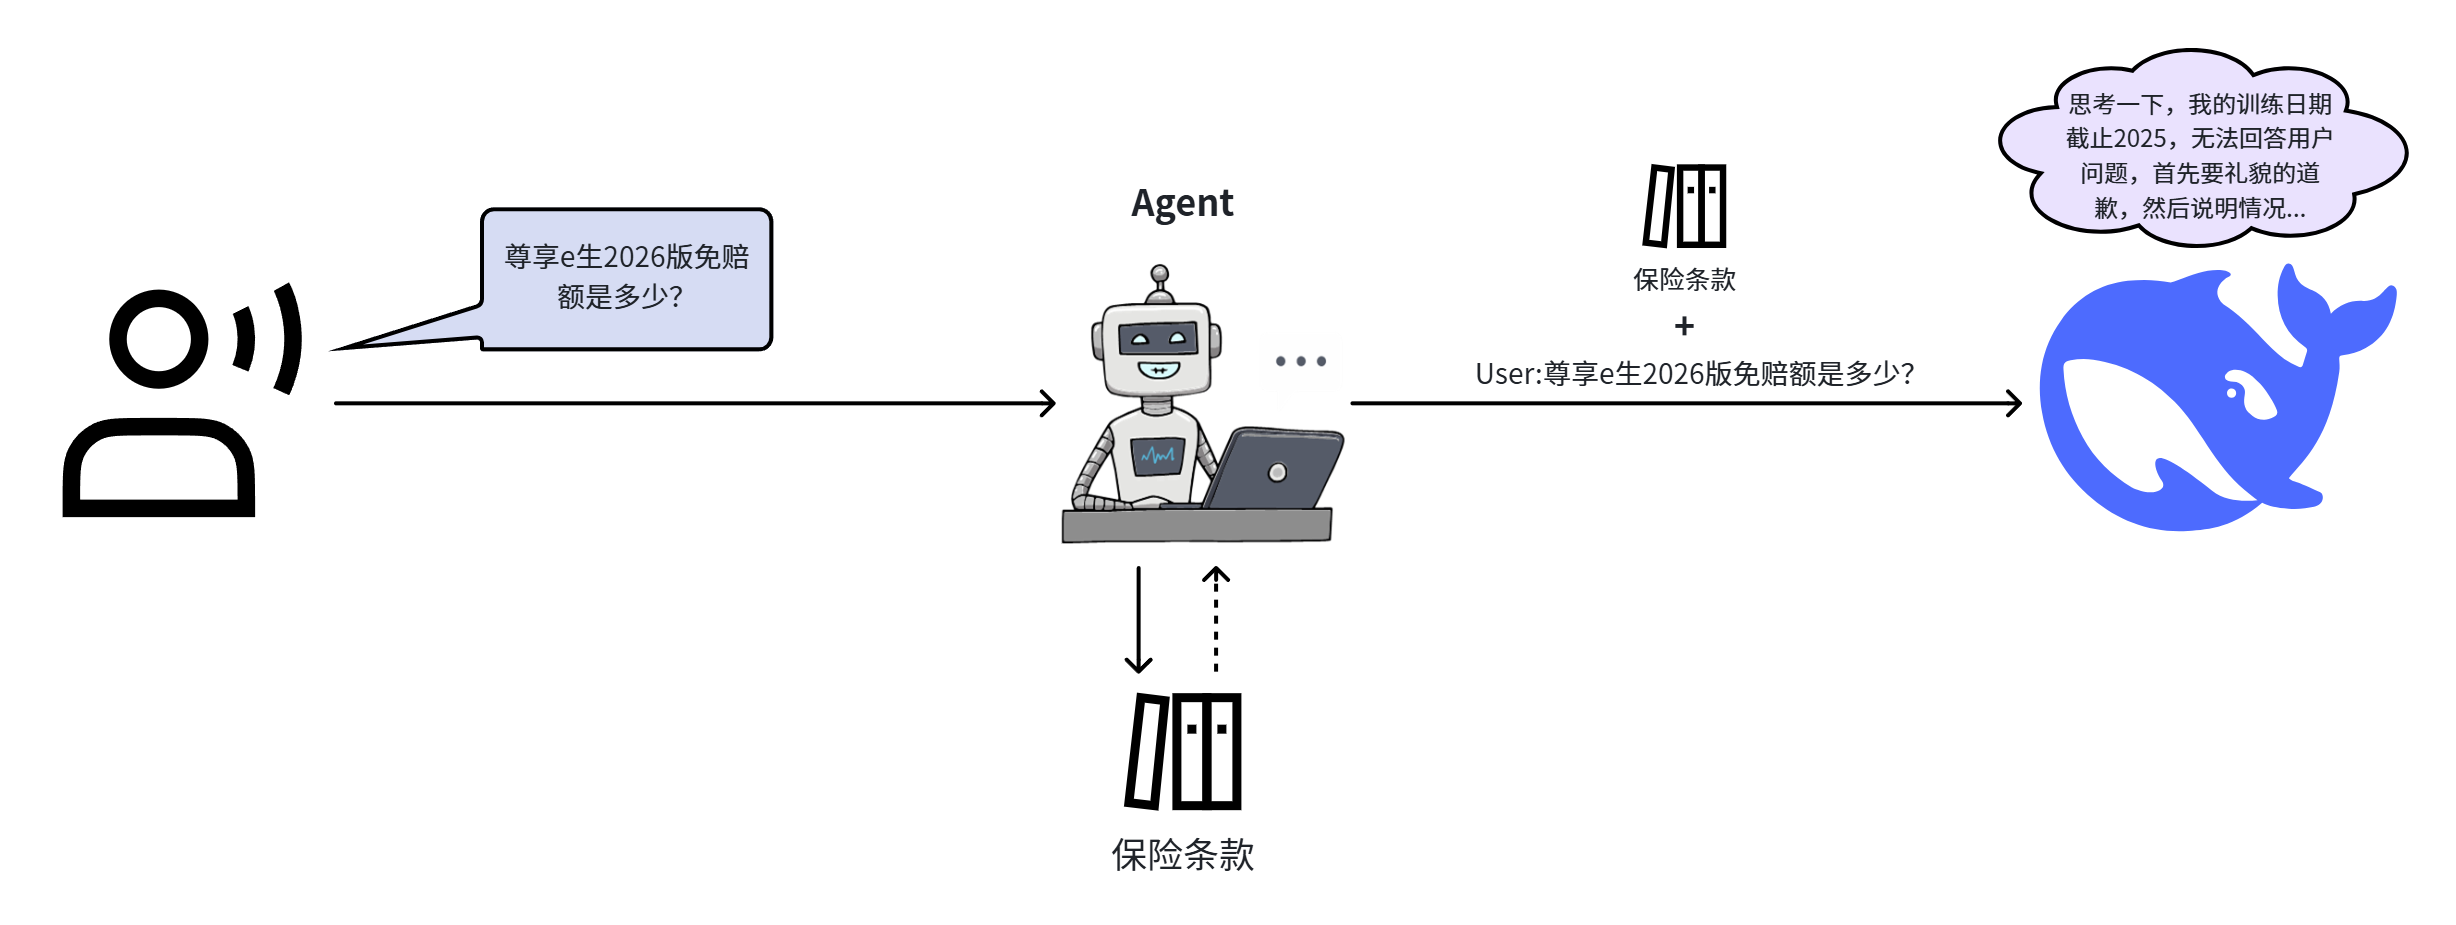

模型拿到了公司完整的保险条款文档，然后根据文档就可以回答用户问题了。

要知道，模型的上下文窗口是有限制的（AI通识篇有介绍过，可以回看视频），目前最大的上下文窗口也就1M token.
而作为一家保险商城，保险数量众多，其保险条款文档总数据量可能达到GB级别！！远远超过了模型的上下文窗口！
而且，即便上下文没有超出，每次用户提问都输入1M的token的上下午，这也是非常浪费的，毕竟token越多，收费越贵！

### 1.3 知识切分
要想让模型回答超出其训练数据以外的问题，就必须在请求模型时携带额外知识数据（知识库）。但是如果知识库书量太大，就存在两个问题：
- 可能超出模型上下文限制
- 浪费大量Token，成本高

该怎么办呢？

聪明的你应该能想到了：
知识库虽然很大，但回答用户问题并不需要整个知识库啊，与用户问题相关的知识其实只是一小部分。我们可以把知识库切分成一个个的知识片段，当用户提问时，只携带与问题相关的知识片段不就可以了！

没错！

还是以保险商城智能客服为例。商城的保险条款非常多，但我们可以按照一定的规则切分：
- 按保险产品切分，每个产品一个条款文档
- 按条款内容切分，例如：投保范围、保险责任、受益人、保费缴纳、免赔策略、....
- ...

按照上述规则将庞大保险知识库切分为小知识块，然后，当用户提问时，我们找到与之相关的知识块，拼入提示词即可：
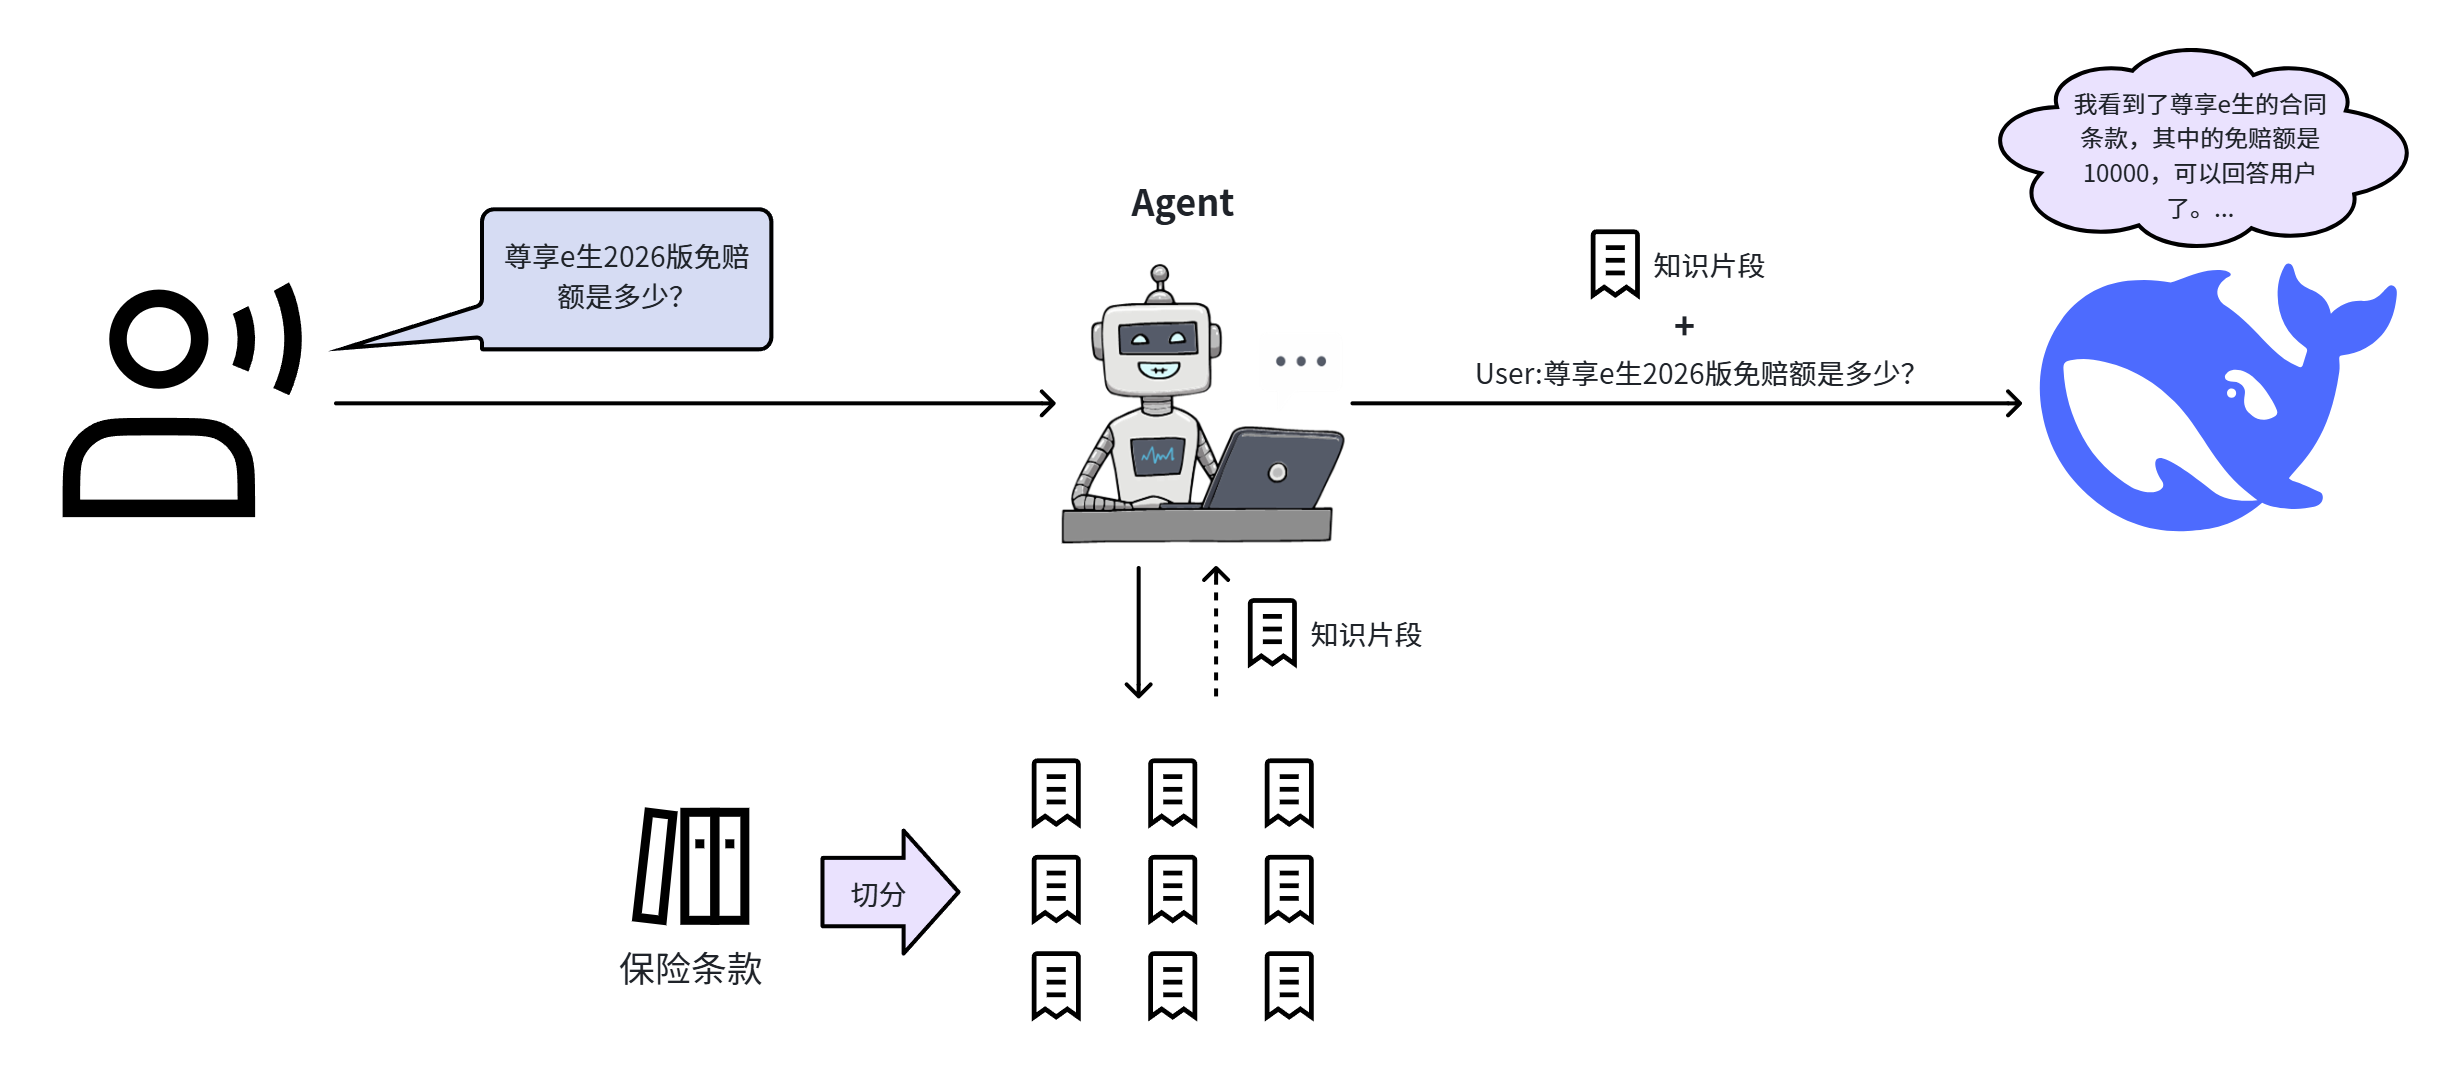

好了，基于文档切分，只携带知识片段的思路，我们解决了之前的两个问题：
- 知识片段体积小，不会超出上下文限制
- 知识片段Token少，成本低

但是，新的问题来了：
切分后知识片段那么多，我怎么知道哪一个片段是与用户问题有关的呢？

### 1.4 知识检索
知识库切分成无数的知识片段后，面临一个难题：
如何从海量的知识片段中找到与用户问题相关的那一个呢？

可能有同学会想：
这很简单啊，把知识片段存入elasticsearch，拿着用户问题，基于全文检索算法搜索就行了。

没错，这是一个办法，也能解决用户的一些问题。但并不能保证每次都能检索到正确的答案。

例如，用户问：我得过肝炎，能买这款产品呢？

这个问题的语义是想问承保范围问题，但是如果你用关键字全文检索，是很难找到对应条款的。所以，针对这类问题我们必须从语义分析来检索，找到语义上与用户问题最接近的知识片段。

用户问题、知识片段都是文字，也就是说我们需要找到一种办法判断两端文字语义是否接近。

那么，我们该如何基于语义判断两段文字是否接近呢？

#### 1.4.1 向量相似度
在AI通识与基础篇，我们介绍Transformer时提到过，模型理解人类语言的方式就是Word Embedding，也就是把词转为多维向量，这些向量映射到多维空间时，不同方向、大小就具备不同的语义。

当然，在知识检索时我们不是要把每个词转为向量，而是把用户的问题（一句话）转为向量，把知识片段（一段话）转为向量，然后就可以通过比较向量相似度来判断两者的含义是否接近了。

那么，如何衡量向量相似度呢？

向量既然是在空间中，两个向量之间就一定能计算距离。

多维空间不好理解，我们以二维向量为例，向量之间的距离常见的计算方法有：
- 余弦相似度（Cosine similarity）：两个向量之间的夹角。
- 欧氏距离（Euclidean distance ）：两点之间的直线距离。
- 点积（Dot product）：一个向量在另一个向量上的投影量

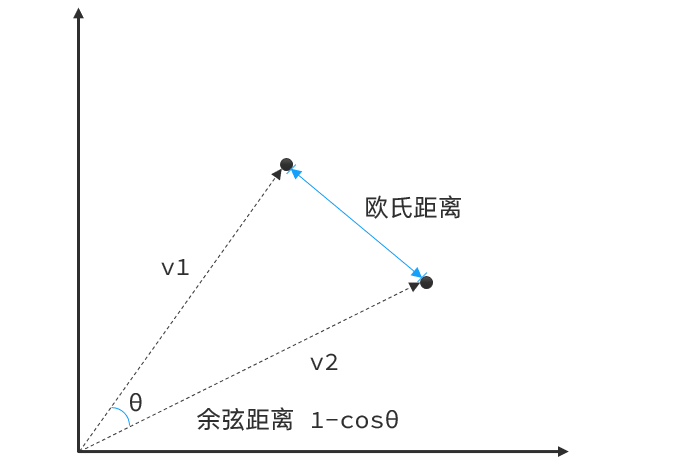

通常，两个向量之间距离越近，我们认为两个向量的相似度越高（距离值越小，相似度越高）

所以，当我们把文本转为向量，就可以通过向量距离来判断文本的相似度了。

现在，有不少的专门的向量模型，就可以实现将文本向量化。一个好的向量模型，就是要尽可能让文本含义相似的向量，在空间中距离更近：

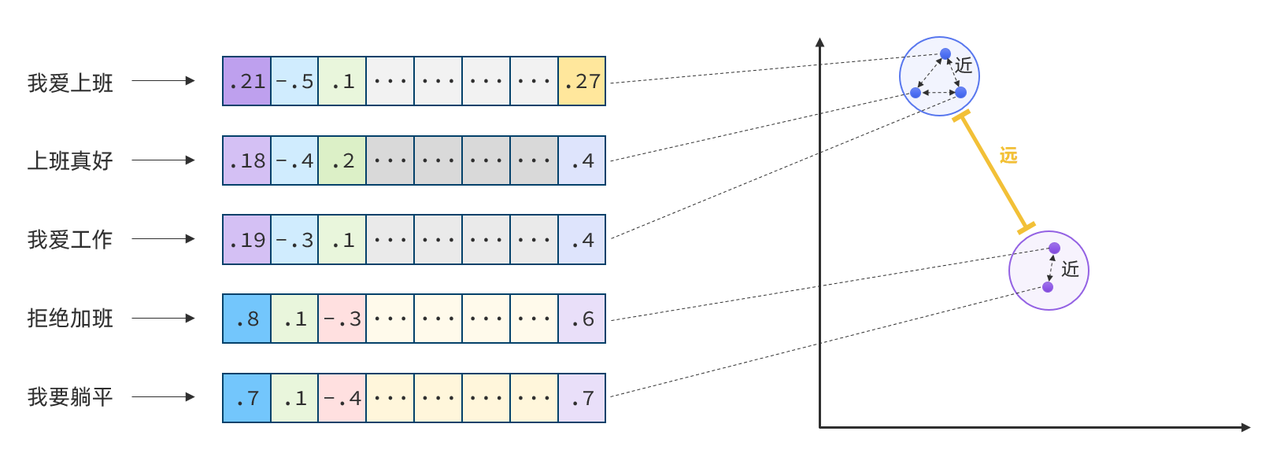

例如，阿里云百炼平台就提供了很多用于知识检索的向量模型：

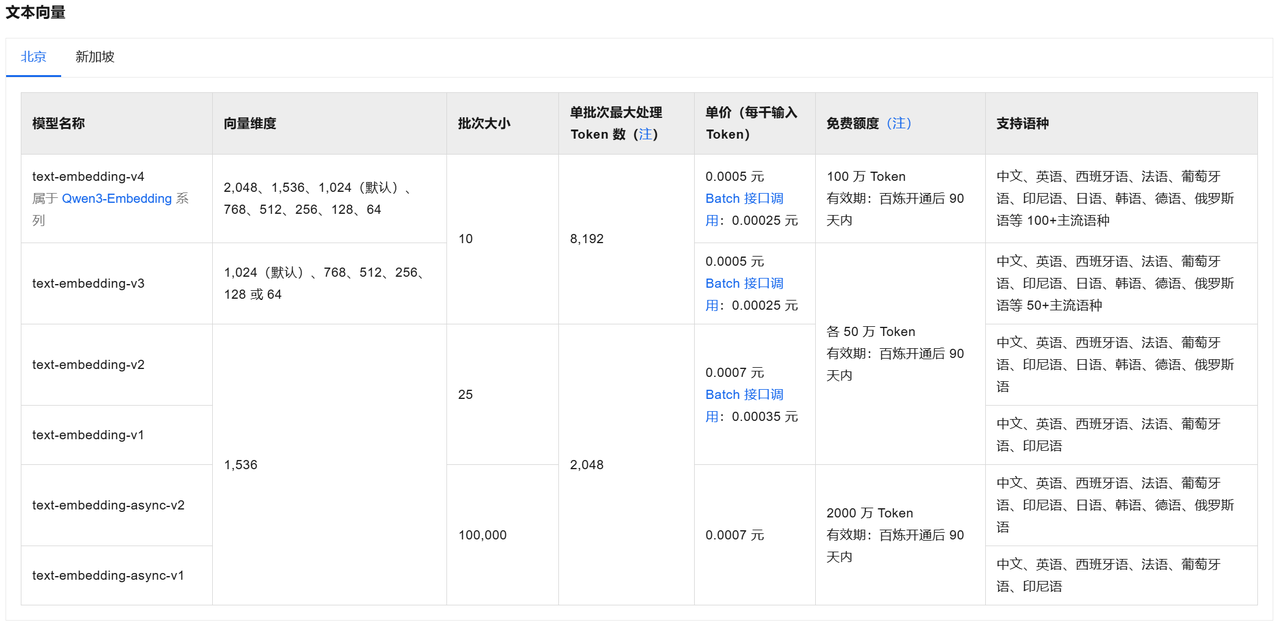

仅仅有向量模型还不够，假如知识切分后有成千上万的知识块（chunk），每一块都有自己的向量值，要在这么多知识块中找出与用户问题相关的向量，需要大量的计算，很麻烦。

那么，我们该如何简单、高效的检索知识片段呢？

#### 1.4.2 向量数据库
向量数据库的主要作用有两个：
- 存储向量数据（知识片段）
- 基于相似度检索向量数据（知识片段）

LangChain中支持市面上常见的各种向量数据库，具体可查看官方文档：
https://docs.langchain.com/oss/python/integrations/vectorstores

目前，企业常用向量数据库可以分为三类：
- 专用的向量数据库：这些产品从底层专为向量检索设计，在高并发、低延迟、海量数据场景下表现最佳。
- 传统数据库集成向量功能：通过插件或新增模块支持向量检索，优点是复用现有运维能力和生态
- 云原生向量数据库：运维成本较低

新兴专用向量数据库

| 数据库名称 | 核心特点 | 典型企业场景 |
| --- | --- | --- |
| Pinecone | 全托管、无需运维、索引优化强 | 适合不希望管理基础设施的SaaS公司、初创企业。 |
| Milvus | 最流行的开源向量数据库，功能全面（支持多种索引、混合查询）。 | 适合有数据安全要求、需要自建或私有化部署的中大型企业。 |
| Qdrant | 用Rust编写，性能极高，支持丰富的过滤条件（Payload）。 | 适合需要复杂元数据过滤的场景（如电商、社交推荐）。 |
| Weaviate | 内置ML模型（可直接向量化数据），支持GraphQL接口。 | 适合希望简化数据预处理流程、使用GraphQL的团队。 |
| Chroma | 轻量级、嵌入式使用（类似SQLite），与LangChain集成最紧密。 | 适合原型验证、AI应用快速开发、个人/小团队项目。 |

传统数据库新增向量功能

| 产品名称 | 向量功能特点 | 常见用途 |
| --- | --- | --- |
| Elasticsearch | 通过dense_vector字段和knn查询支持向量搜索。 | 已有ES集群的企业、日志+向量混合搜索场景。 |
| Pgvector（PostgreSQL扩展） | 最流行的关系型数据库向量扩展，简单稳定，支持精确/近似搜索。 | 技术栈以PostgreSQL为主、不想引入新组件的企业。 |
| Redis | 通过RediSearch模块提供向量相似度搜索。 | 需要超低延迟（缓存级）、实时推荐场景。 |
| ClickHouse | 通过余弦/欧氏距离函数支持向量检索。 | 大规模数据分析+向量检索结合的OLAP场景。 |

企业开发，首推Milvus数据库，性能最好，而且开源免费
个人测试，用Milvus lite或Chroma都可以，都支持本地嵌入（类似Sqlite）

有了向量数据库，我们就无需自己检索向量了，全部交给向量数据库即可。

### 1.5 最终蓝图
到这里为止，RAG所需要的核心技术和原理就清楚了，这个时候你也能理解RAG名字的由来了。

RAG，Retrieval-Augmented Generation，关键词：
- 检索：就是利用向量相似度检索知识片段
- 增强：用检索到的知识片段增强模型，减少幻觉
- 生成：模型基于知识片段生成答案

#### 1.5.1 RAG核心流程
综上所述，RAG分为两大阶段：
- 离线阶段：负责构建知识库
  1. 知识加载：读取各种来源的知识库数据，解析、清洗数据，形成文档（Documents）。
  2. 知识切分：把清洗后的知识文档切分成一个个的知识片段（Chunks）
  3. 向量化：利用向量模型将知识片段转为向量，使得语义相近的文本在该向量空间中彼此邻近
  4. 存储向量：像处理好的向量及对应的知识片段存入向量数据库
- 在线阶段：负责检索知识，生成回答
  1. 问题向量化：利用向量模型（必须与离线阶段同一个模型）将用户问题转为向量
  2. 知识召回：在向量数据库中检索与问题向量最相似的文档的TopN
  3. 生成回答：把检索到的知识片段与用户提问组织为新提示词，发给大模型，生成回答
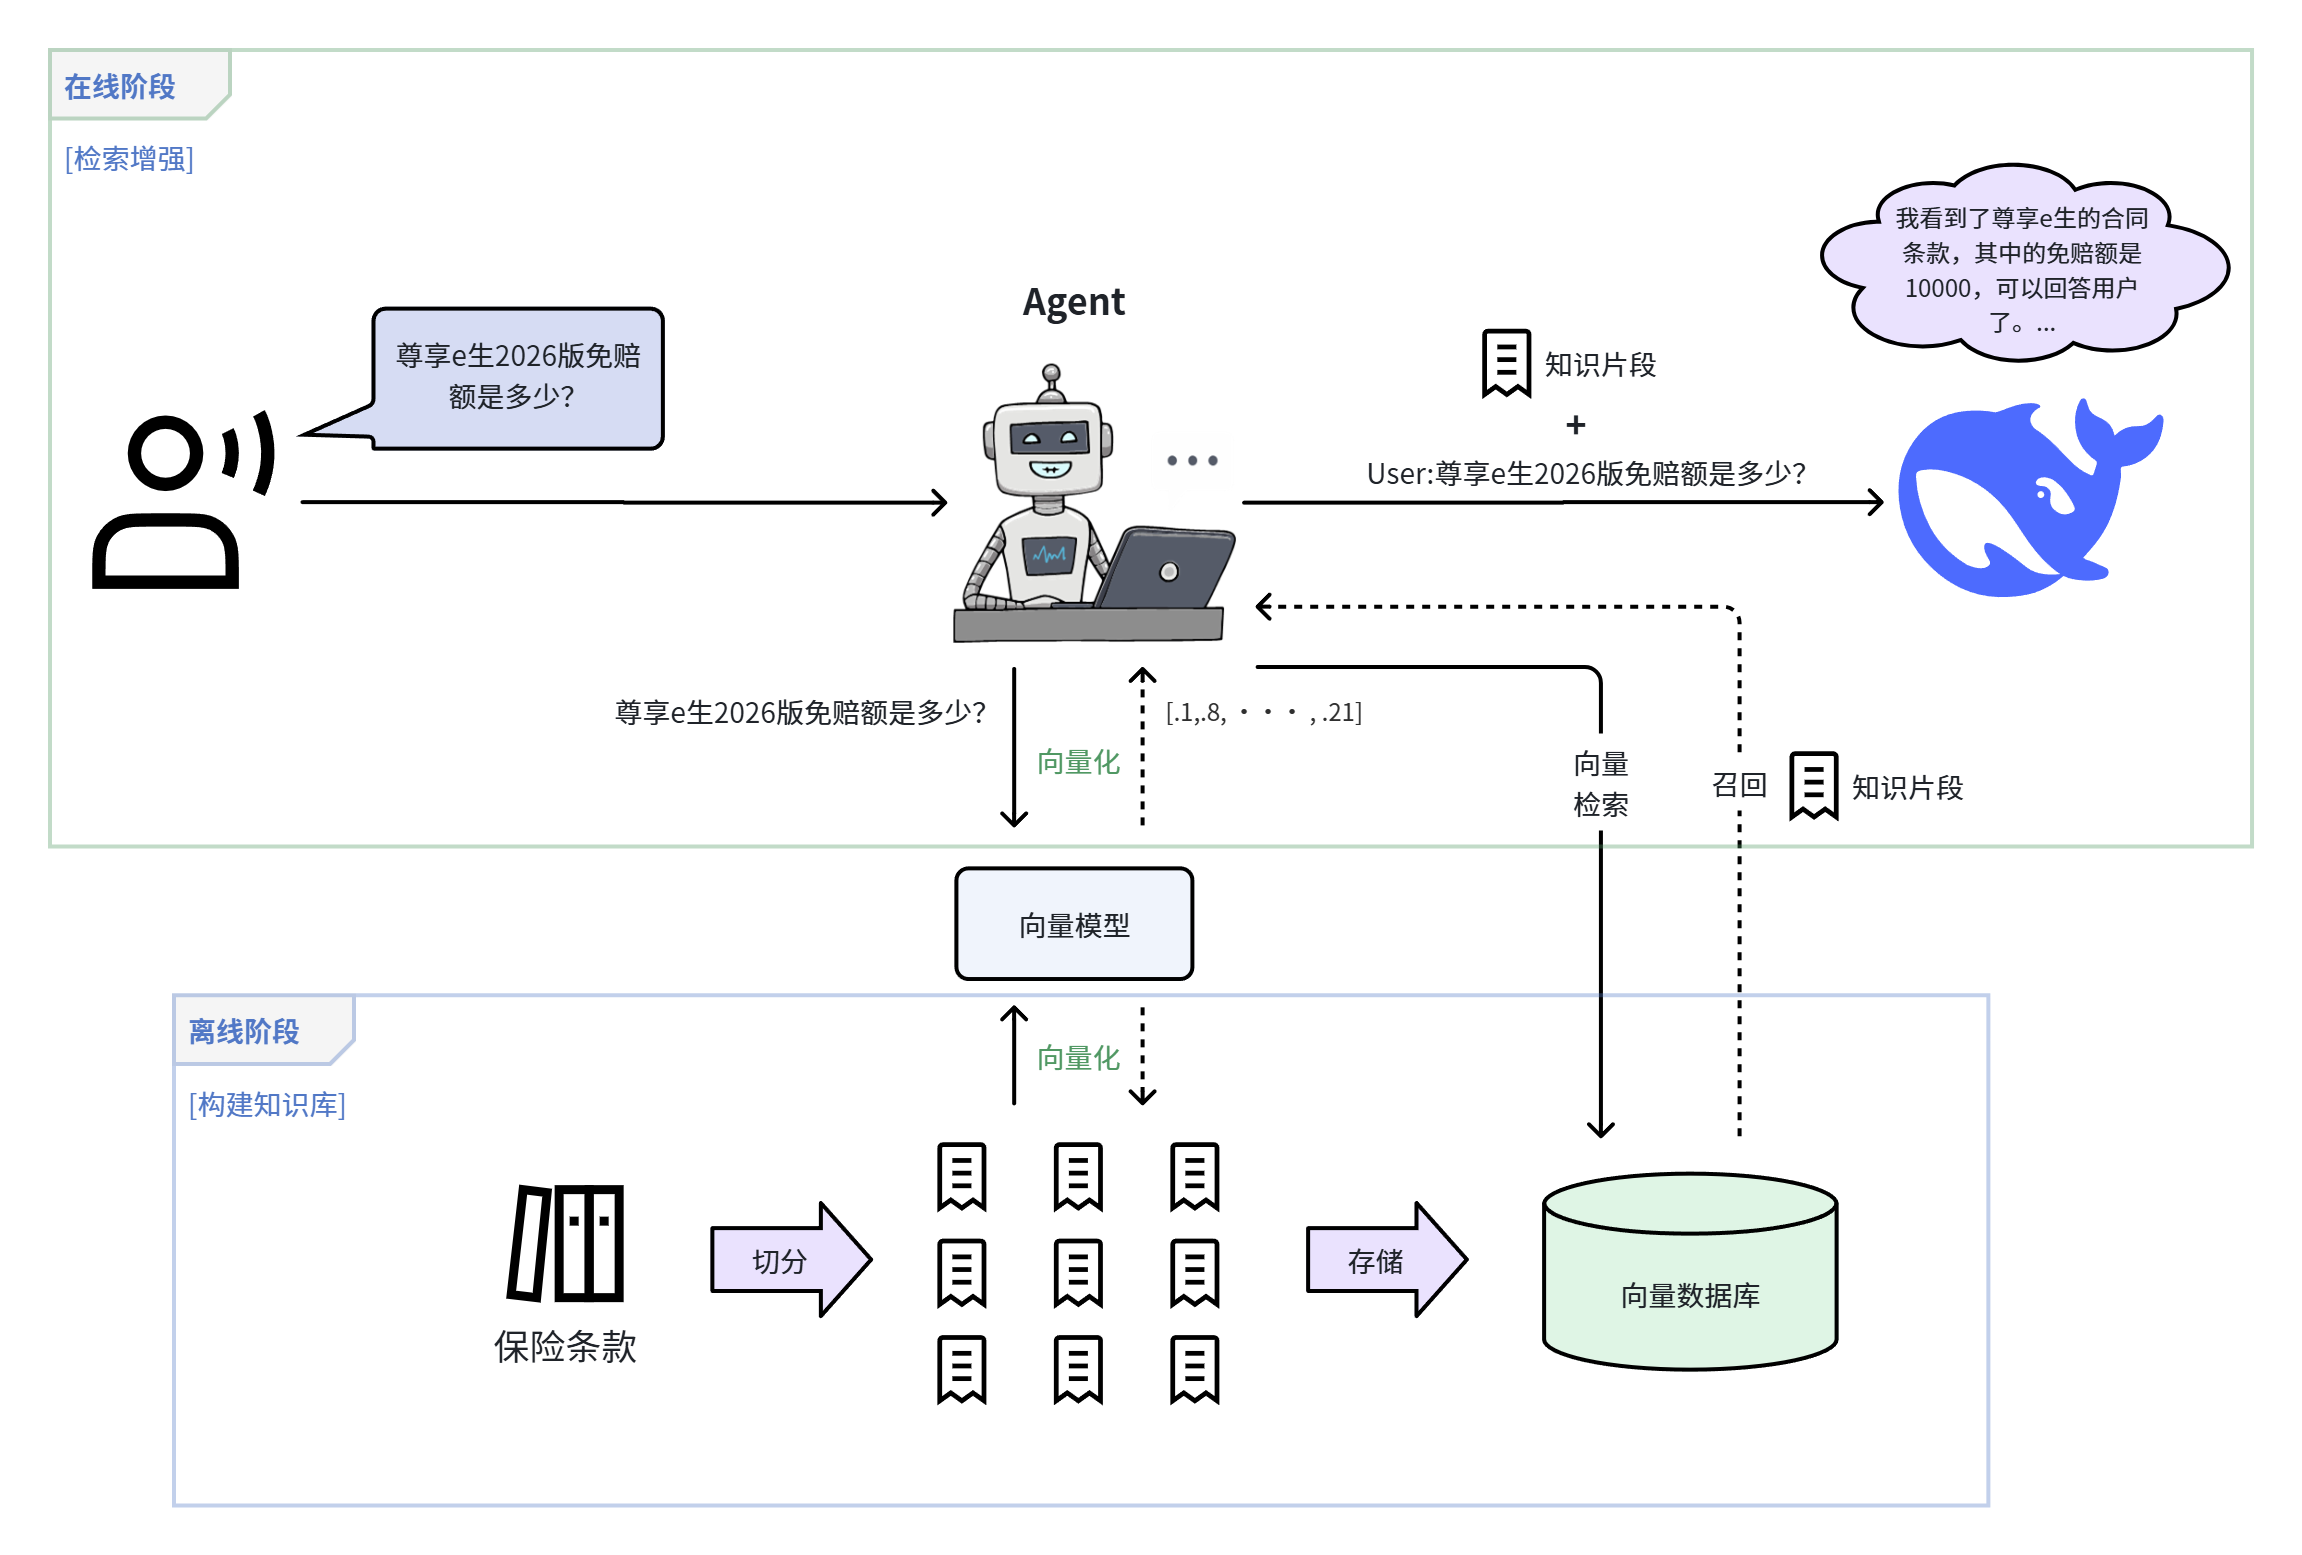

#### 1.5.2 LangChain的RAG组件
LangChain为了简化RAG的开发，为我们提供了大量组件，满足RAG每一个流程的实现。

主要的组件包括：
- 离线阶段
  1. 知识加载：LangChain提供了Document Loader组件
  2. 知识切分：LangChain提供了Text Splitter组件
  3. 向量化：LangChain提供了Embeddings接口，兼容各类向量模型
  4. 存储向量：LangChain提供了VectorStore接口，兼容各类向量数据库
- 在线阶段：负责检索知识，生成回答
  1. 问题向量化：同样基于Embeddings模型接口
  2. 知识召回：LangChain提供了Retrievers组件，简化知识片段的检索操作
  3. 生成回答：直接调用模型即可

#### 1.5.3 RAG代码预览
最后，我们一起先看看LangChain实现RAG的代码流程，有一个整体的认知。

完整代码如下：

In [1]:
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import CharacterTextSplitter
from langchain_community.embeddings import DashScopeEmbeddings
from langchain_core.vectorstores import InMemoryVectorStore
from langchain.tools import tool
from langchain.chat_models import init_chat_model
from langchain.agents import create_agent

import os
from dotenv import load_dotenv
load_dotenv()
# ===============一、构建知识库阶段====================
# =============1.加载文档===============
loader = PyPDFLoader(
    "resources/贵州茅台研报.pdf",
    mode="single", # single \ page
)
docs = loader.load()
print(f"文档数量:{len(docs)}")

# =============2.切分文档===============
# 创建递归切分器
splitter = CharacterTextSplitter(separator="\n", chunk_size=1000, chunk_overlap=150)
# 切分文档
chunks = splitter.split_documents(docs)
print(f"分块数量：{len(chunks)}")

# =============3.向量化===============
# 向量模型，这里用阿里云的向量模型
embeddings = DashScopeEmbeddings(
    model="text-embedding-v3",
    dashscope_api_key=os.getenv("DASHSCOPE_API_KEY")
)

# 创建向量库，需要指定向量模型，存储文档时会自动调用向量模型完成向量化
vectorstore = InMemoryVectorStore(embedding=embeddings)
# 添加文档
vectorstore.add_documents(chunks)


# ==============二、在线问答阶段================
llm = init_chat_model("deepseek-chat")

def try_rag(query: str):
    # 1.检索文档（VectorStore会自动把问题向量化，召回相关知识片段）
    retrieved_docs = vectorstore.similarity_search(query, k=2)
    # 2.拼接上下文提示词
    content = "\n\n".join(doc.page_content for doc in retrieved_docs)
    prompt = f"""你基于我提供的报告回答用户问题，报告中没提及的就说不知道，不要自己编造答案.
    report: ```{content}```
    query: {query}"""
    # 3.调用模型，生成答案
    response = llm.invoke(prompt)
    return response.content

C:\Users\feng\AppData\Local\Temp\ipykernel_11996\171864768.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader


文档数量:1
分块数量：11


In [6]:
print(try_rag("茅台收盘价多少"))
print(try_rag("茅台2025年的市盈率和市净率是多少"))

根据您提供的报告，贵州茅台的收盘价为1,315.00元（时间2026.05.20）。
根据您提供的报告，其中没有提及贵州茅台2025年的市盈率（PE）和市净率（PB）数据。报告中仅提到当前股价对应PE为20倍（基于26/27/28年盈利预测），但未给出2025年的具体市盈率和市净率数值。因此，无法回答您的问题。


文档中明明有相关信息，但是回答却没有，这就是说现在这个RAG系统在知识检索上存在问题。

可见，LangChain尽管提供了组件能帮助我们快速搭建RAG系统，但要想开发出一个稳定、可靠的RAG系统，还有很多需要优化的地方。

接下来我们就分为两个阶段逐一学习这些RAG组件的用法，以及其中的优化细节：
- 第1节. 构建知识库：核心关注离线阶段的每个组件用法及企业优化方案
- 第2节. RAG Agent: 核心关注如何利用LangChain构建RAG Agent，实现在线阶段的知识检索和问答，并通过优化手段提高回答的准确度
- 第3节. RAG评估: 核心是RAG系统的健康指标，如何利用工具去评估RAG系统的能力